In [84]:
import json
import os
import boto3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np
pd.set_option("display.max_columns",50)
from io import StringIO

In [54]:
aws_access_key = os.getenv("AWS_ACCESS_KEY")
aws_secret_key = os.getenv("AWS_SECRET_KEY")

In [55]:
s3=boto3.client("s3", aws_access_key_id=aws_access_key, aws_secret_access_key=aws_secret_key)

In [56]:
bucket = "edem1550-chicago-taxi-bb"

dim_community_areas_path = "transformed_data/dim_community_areas/dim_community_areas.csv"
dim_company_path = "transformed_data/dim_company/dim_company.csv"
dim_date_path = "transformed_data/dim_date/dim_date.csv"
dim_payment_type_path = "transformed_data/dim_payment_type/dim_payment_type.csv"
dim_weather_path = "transformed_data/dim_weather/"
fact_taxi_trips_path = "transformed_data/fact_taxi_trips/"

In [57]:
def read_file_from_s3(
    s3, 
    bucket:str,
    key:str, 
    file_format:str="csv"
):
    
    """
    Reads a file from given S3 bucket
    Args:
        s3 (boto3.client): S3 client
        bucket (str): S3 bucket name where the file stored
        key (str): Path within the S3 bucket
        file_format (str, optional): File format. Defaults to "csv". Can be also "json"

    Returns:
        pandas.DataFrame: Dataframe
    """

    BUCKET= bucket
    response= s3.get_object(Bucket=BUCKET, Key=key)
    content= response["Body"].read().decode("utf-8")
    if file_format == "csv":
        return pd.read_csv(StringIO(content))
    elif file_format == "json":
        return json.loads(content)
    else:
        raise ValueError("File format not supported, use 'csv' or 'json' ")



In [58]:
dim_community_areas = read_file_from_s3(s3, bucket, dim_community_areas_path)
dim_company = read_file_from_s3(s3, bucket, dim_company_path)
dim_date = read_file_from_s3(s3, bucket, dim_date_path)
dim_payment_type = read_file_from_s3(s3, bucket, dim_payment_type_path)

In [59]:
dim_payment_type.head()

,payment_type_id,payment_type
0,1,Cash
1,2,Mobile
2,3,Credit Card
3,4,No Charge
4,5,Prcard


In [60]:
fact_taxi_trips_list = []
dim_weather_list = []

In [61]:
for file in s3.list_objects(Bucket=bucket, Prefix=fact_taxi_trips_path)["Contents"]:
    taxi_key = file["Key"]
    taxi_raw_file_name=file["Key"].split("/")[-1]
    if taxi_raw_file_name.split(".")[-1] =="csv":
        daily_file_name = fact_taxi_trips_path + taxi_raw_file_name
        taxi_trip_daily = read_file_from_s3(s3, bucket, daily_file_name)
        fact_taxi_trips_list.append(taxi_trip_daily)
        print(f"{taxi_raw_file_name} has been added")


taxi_2025-09-23.csv has been added
taxi_2025-09-24.csv has been added
taxi_2025-09-25.csv has been added
taxi_2025-09-26.csv has been added
taxi_2025-09-27.csv has been added
taxi_2025-09-28.csv has been added
taxi_2025-09-29.csv has been added
taxi_2025-09-30.csv has been added
taxi_2025-10-01.csv has been added
taxi_2025-10-02.csv has been added
taxi_2025-10-03.csv has been added
taxi_2025-10-04.csv has been added
taxi_2025-10-05.csv has been added
taxi_2025-10-06.csv has been added
taxi_2025-10-07.csv has been added
taxi_2025-10-08.csv has been added
taxi_2025-10-09.csv has been added
taxi_2025-10-10.csv has been added
taxi_2025-10-11.csv has been added
taxi_2025-10-12.csv has been added
taxi_2025-10-13.csv has been added
taxi_2025-10-14.csv has been added
taxi_2025-10-15.csv has been added


In [62]:
fact_taxi_trips = pd.concat(fact_taxi_trips_list, ignore_index=True)

In [63]:
dim_weather_list = []

In [64]:
for file in s3.list_objects(Bucket=bucket, Prefix=dim_weather_path)["Contents"]:
    weather_key = file["Key"]
    weather_raw_file_name=file["Key"].split("/")[-1]
    if weather_raw_file_name.split(".")[-1] =="csv":
        daily_file_name = dim_weather_path + weather_raw_file_name
        weather_daily = read_file_from_s3(s3, bucket, weather_key)   
        dim_weather_list.append(weather_daily)
        print(f"{weather_raw_file_name} has been added")

weather_2025-09-23.csv has been added
weather_2025-09-24.csv has been added
weather_2025-09-25.csv has been added
weather_2025-09-26.csv has been added
weather_2025-09-27.csv has been added
weather_2025-09-28.csv has been added
weather_2025-09-29.csv has been added
weather_2025-09-30.csv has been added
weather_2025-10-01.csv has been added
weather_2025-10-02.csv has been added
weather_2025-10-03.csv has been added
weather_2025-10-04.csv has been added
weather_2025-10-05.csv has been added
weather_2025-10-06.csv has been added
weather_2025-10-07.csv has been added
weather_2025-10-08.csv has been added
weather_2025-10-09.csv has been added
weather_2025-10-10.csv has been added
weather_2025-10-11.csv has been added
weather_2025-10-12.csv has been added
weather_2025-10-13.csv has been added
weather_2025-10-14.csv has been added
weather_2025-10-15.csv has been added


In [65]:
dim_weather = pd.concat(dim_weather_list, ignore_index=True)

dim_weather.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 552 entries, 0 to 551
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   datetime       552 non-null    object 
 1   temperature    552 non-null    float64
 2   wind_speed     552 non-null    float64
 3   rain           552 non-null    float64
 4   precipitation  552 non-null    float64
dtypes: float64(4), object(1)
memory usage: 21.7+ KB


### Create datamodel

In [66]:
fact_taxi_trips_full = pd.merge(fact_taxi_trips, dim_weather, left_on="datetime_for_weather", right_on="datetime")
fact_taxi_trips_full = fact_taxi_trips_full.drop(columns=["datetime", "datetime_for_weather"])

In [67]:
fact_taxi_trips_full = pd.merge(fact_taxi_trips_full, dim_company, left_on="company_id", right_on="company_id")
fact_taxi_trips_full = fact_taxi_trips_full.drop(columns=["company_id"])

In [68]:
fact_taxi_trips_full = pd.merge(fact_taxi_trips_full, dim_payment_type, left_on="payment_type_id", right_on="payment_type_id")
fact_taxi_trips_full = fact_taxi_trips_full.drop(columns=["payment_type_id"])

In [69]:
fact_taxi_trips_full = pd.merge(fact_taxi_trips_full, dim_community_areas, left_on="pickup_community_area_id", right_on="area_code")
fact_taxi_trips_full = fact_taxi_trips_full.drop(columns=["pickup_community_area_id","area_code",])
fact_taxi_trips_full.rename(columns={"community_area":"pickup_community_area_name"}, inplace=True)

In [70]:
fact_taxi_trips_full = pd.merge(fact_taxi_trips_full, dim_community_areas, left_on="dropoff_community_area_id", right_on="area_code")
fact_taxi_trips_full = fact_taxi_trips_full.drop(columns=["dropoff_community_area_id","area_code",])
fact_taxi_trips_full.rename(columns={"community_area":"dropoff_community_area_name"}, inplace=True)

In [71]:
dim_date["date"] = pd.to_datetime(dim_date["date"])
fact_taxi_trips_full["trip_start_timestamp"] = pd.to_datetime(fact_taxi_trips_full["trip_start_timestamp"])

fact_taxi_trips_full["trip_start_date"] = pd.to_datetime(fact_taxi_trips_full["trip_start_timestamp"].dt.date)


In [72]:
fact_taxi_trips_full = pd.merge(fact_taxi_trips_full, dim_date, left_on="trip_start_date", right_on="date")
fact_taxi_trips_full = fact_taxi_trips_full.drop(columns=["trip_start_date","date"])
fact_taxi_trips_full

,trip_id,taxi_id,trip_start_timestamp,trip_end_timestamp,trip_seconds,trip_miles,fare,tips,tolls,extras,trip_total,pickup_centroid_latitude,pickup_centroid_longitude,dropoff_centroid_latitude,dropoff_centroid_longitude,temperature,wind_speed,rain,precipitation,company,payment_type,pickup_community_area_name,dropoff_community_area_name,year,month,day,day_of_week,is_weekend
0,93446c9c1098f23e505164659baba263728e620d,02ef8f01232b1b1828f4e5e1b8e8a85cd71b67c449afaf...,2025-09-23 23:45:00,2025-09-24T00:15:00.000,1134,11.60,30.75,0.0,0.0,0.0,30.75,41.763247,-87.616134,41.899602,-87.633308,20.2,12.2,0.0,0.0,City Service,Prcard,Greater Grand Crossing,Near North Side,2025,9,23,2,False
1,928acc35835559e18bfd640170fc2632f18c1b10,6544c8051894de482dd3253d911c3e3d713b43beb93de2...,2025-09-23 23:45:00,2025-09-24T00:00:00.000,726,3.49,11.75,8.0,0.0,0.0,20.25,41.944227,-87.655998,41.922761,-87.699155,20.2,12.2,0.0,0.0,City Service,Credit Card,Lake View,Logan Square,2025,9,23,2,False
2,8f6f96baf9284ac1acd4c2eee2f56dd8ac8d0e7d,f509c57d2f0b196f54d9b751ce2a1b6e956f378841b1e8...,2025-09-23 23:45:00,2025-09-23T23:45:00.000,4,0.00,25.00,2.0,0.0,0.0,27.50,41.878866,-87.625192,41.878866,-87.625192,20.2,12.2,0.0,0.0,City Service,Credit Card,Loop,Loop,2025,9,23,2,False
3,85a4e27c77425d5a8f6d0253585c98f083ddfec8,8d9a2218e0a2c8ae95ec61ac346b42b4e2fe21c484c89d...,2025-09-23 23:45:00,2025-09-24T00:00:00.000,610,9.16,24.25,0.0,0.0,0.0,24.25,41.706588,-87.623367,41.835118,-87.618678,20.2,12.2,0.0,0.0,Globe Taxi,Prcard,Roseland,Douglas,2025,9,23,2,False
4,84db5e3c929af11688df7216e13402a95bf838f6,b5e2695a2f44b9bce7a0a86148ac418802f0067be1f6d4...,2025-09-23 23:45:00,2025-09-23T23:45:00.000,10,0.08,3.25,0.0,0.0,0.0,3.25,41.979071,-87.903040,41.979071,-87.903040,20.2,12.2,0.0,0.0,Sun Taxi,Cash,O'Hare[11],O'Hare[11],2025,9,23,2,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
446944,53a3dba257e80add0a12c5fcdc17cc40ed64e78e,3faa8cd4b08a27471c13be24573d831fea1445947afb30...,2025-10-15 00:00:00,2025-10-15T00:45:00.000,1942,28.29,67.00,14.7,0.0,6.0,88.20,41.980264,-87.913625,41.899602,-87.633308,15.3,12.6,0.0,0.0,Chicago Independents,Credit Card,O'Hare[11],Near North Side,2025,10,15,3,False
446945,4a429e20742d21693c9b4e0385491509af341034,2e82e26afb77e809fe4a44b02a152bdc079623600ae1b7...,2025-10-15 00:00:00,2025-10-15T00:15:00.000,1140,11.80,30.25,0.0,0.0,4.0,34.25,41.792592,-87.769615,41.899602,-87.633308,15.3,12.6,0.0,0.0,Transit Administrative Center Inc,Cash,Garfield Ridge,Near North Side,2025,10,15,3,False
446946,145ef86e849ff92ff8a425dc2332605a60d54e5c,ffda53354c610fd3af1aee46d723028a49014e35f7280c...,2025-10-15 00:00:00,2025-10-15T00:15:00.000,246,0.94,5.50,0.0,0.0,0.0,5.50,41.899602,-87.633308,41.899602,-87.633308,15.3,12.6,0.0,0.0,Flash Cab,Cash,Near North Side,Near North Side,2025,10,15,3,False
446947,497b4f347e35cf3b2518bcacd54390acb4595889,e2c349c7cbb608d552aa0b5814031943f13641ef9e50d8...,2025-10-15 00:00:00,2025-10-15T00:15:00.000,1140,14.40,36.50,8.1,0.0,4.0,48.60,41.980264,-87.913625,41.922686,-87.649489,15.3,12.6,0.0,0.0,Transit Administrative Center Inc,Credit Card,O'Hare[11],Lincoln Park,2025,10,15,3,False


In [73]:
fact_taxi_trips_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 446949 entries, 0 to 446948
Data columns (total 28 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   trip_id                      446949 non-null  object        
 1   taxi_id                      446946 non-null  object        
 2   trip_start_timestamp         446949 non-null  datetime64[ns]
 3   trip_end_timestamp           446949 non-null  object        
 4   trip_seconds                 446949 non-null  int64         
 5   trip_miles                   446949 non-null  float64       
 6   fare                         446949 non-null  float64       
 7   tips                         446949 non-null  float64       
 8   tolls                        446949 non-null  float64       
 9   extras                       446949 non-null  float64       
 10  trip_total                   446949 non-null  float64       
 11  pickup_centroid_latitude  

### Visualizations

#### AVG trip_miles per day (bar chart)

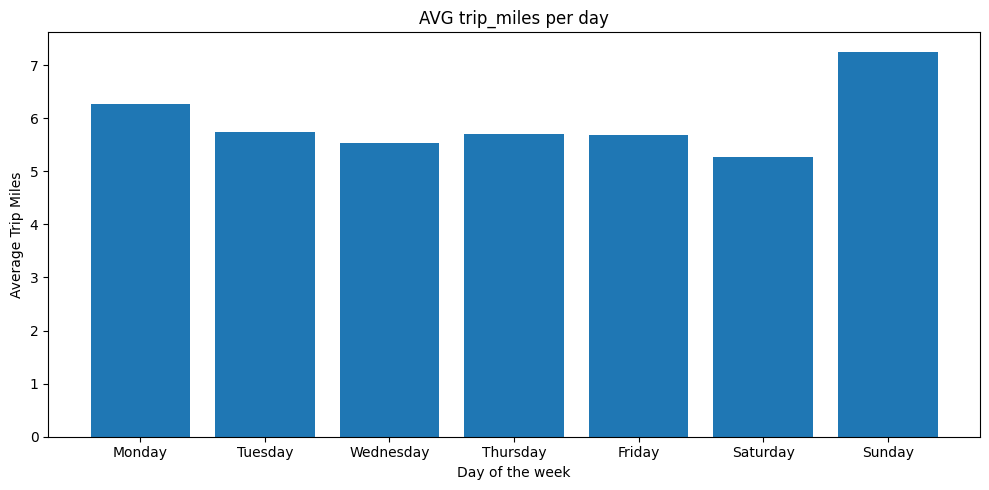

In [74]:
# Create weekday column

fact_taxi_trips_full['weekday'] = fact_taxi_trips_full['trip_start_timestamp'].dt.dayofweek

# Create dictionary for weekday names

numbers_to_weekdays = {
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
}

# Merge back weekdays to df

fact_taxi_trips_full['weekday_name']=fact_taxi_trips_full['weekday'].map(numbers_to_weekdays)

# Calculate average trip miles per weekday

avg_miles = (
    fact_taxi_trips_full.groupby('weekday_name')['trip_miles']
    .mean()
    .reindex(numbers_to_weekdays.values())
)

# Create bar chart

plt.figure(figsize=(10,5))
plt.bar(avg_miles.index, avg_miles.values)

plt.title('AVG trip_miles per day')
plt.xlabel('Day of the week')
plt.ylabel('Average Trip Miles')

plt.tight_layout()
plt.show()

#### AVG fare per hour (bar chart)

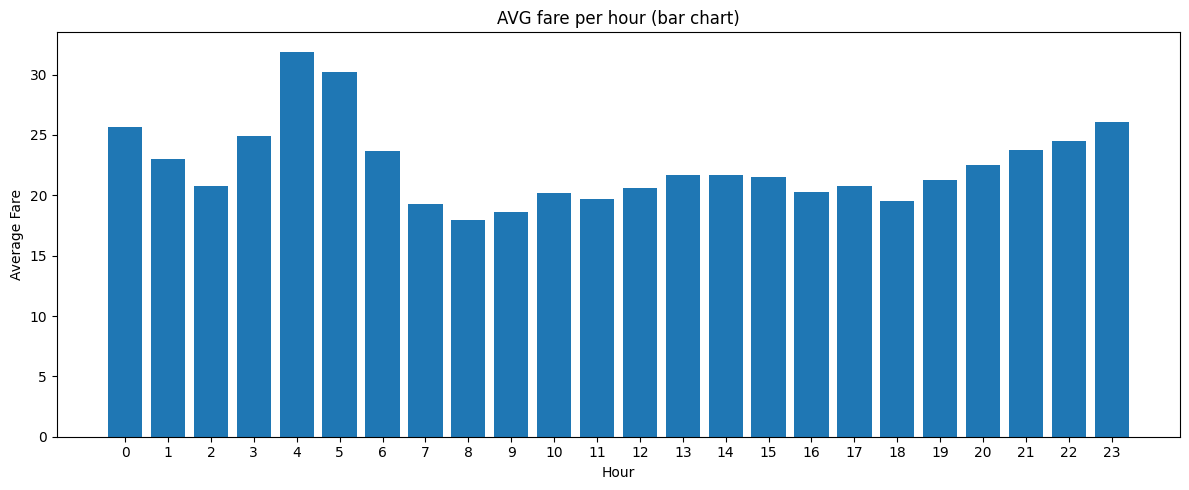

In [75]:
# Calculate hour data

fact_taxi_trips_full['hour'] = fact_taxi_trips_full['trip_start_timestamp'].dt.hour

# Calculate average fare per hour

avg_fare_by_hour = (
    fact_taxi_trips_full.groupby('hour')['fare']
    .mean()
    .reindex(range(24))
)

# Create bar chart

plt.figure(figsize=(12, 5))
plt.bar(avg_fare_by_hour.index,avg_fare_by_hour.values)
plt.title('AVG fare per hour (bar chart)')
plt.xlabel('Hour')
plt.ylabel('Average Fare')
plt.xticks(range(24))
plt.tight_layout()
plt.show()

#### Share of company revenues in the examined period (donut chart)

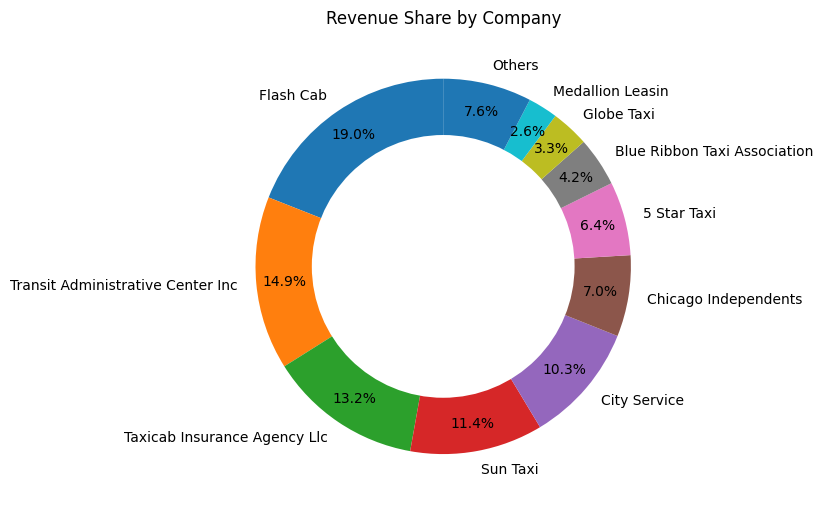

In [78]:
# Remove fares with 0

fact_taxi_trips_full_cleaned = fact_taxi_trips_full[fact_taxi_trips_full['fare'] > 0]

# Aggregate total revenue per company

revenue_by_company = (
    fact_taxi_trips_full_cleaned.groupby('company')['fare']
    .sum()
    .sort_values(ascending=False)
)

# Limit to top 10 companies

top_n = 10
top_companies = revenue_by_company.head(top_n)
others=revenue_by_company.iloc[top_n:].sum()

revenue_plot = pd.concat([top_companies,pd.Series({'Others':others})])


# Create the donut chart (with percentage values)

plt.figure(figsize=(8,8))

wedges, texts, autotexts = plt.pie(
    revenue_plot.values,
    labels=revenue_plot.index,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.85
)

#Create the whole of the donut

centre_circle = plt.Circle((0,0), 0.70, fc='white')
plt.gca().add_artist(centre_circle)

plt.title('Revenue Share by Company')
plt.tight_layout()
plt.show()


#### Number of taxi trips by payment type (pie chart)

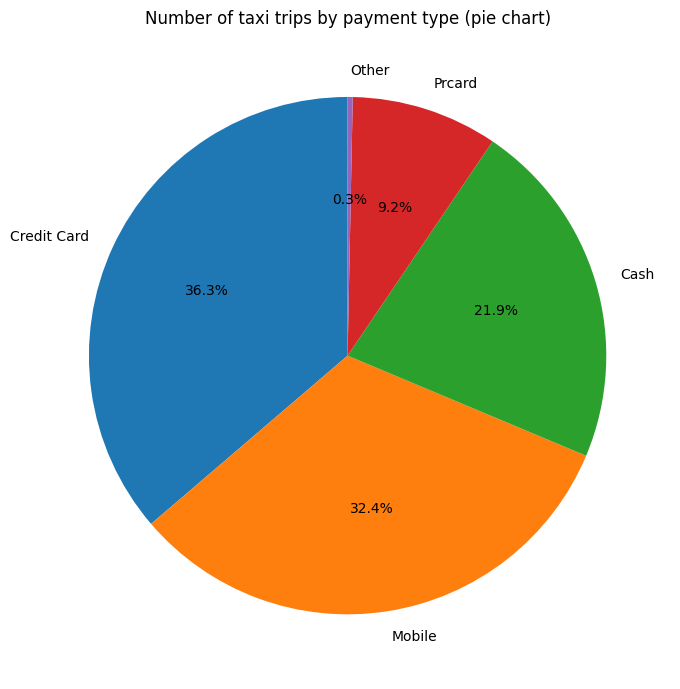

In [83]:
# Count number of trips per payment type with removing unknown values

fact_taxi_trips_full_wo_unknown = fact_taxi_trips_full[
    fact_taxi_trips_full['payment_type'] != 'Unknown'
]

payment_counts = (
    fact_taxi_trips_full_wo_unknown['payment_type']
    .dropna()
    .value_counts()
)

# Group rare payments methods to 'Other' category

threshold = 0.02
total = payment_counts.sum()

major = payment_counts[payment_counts / total >= threshold]
other = payment_counts[payment_counts / total < threshold].sum()

payment_plot = pd.concat([major, pd.Series({'Other': other})])

# Create pie chart

plt.figure(figsize=(7,7))
plt.pie(
    payment_plot.values,
    labels=payment_plot.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Number of taxi trips by payment type (pie chart)')
plt.tight_layout()
plt.show()

#### Correlation between temperature and trip mile data (scatterplot)

R² = 0.000


C:\Users\Adam\AppData\Local\Temp\ipykernel_18236\2994343214.py:38: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\Ádám\Desktop\DATA_ANALYST_FILES\CUBIX_Data_Engineer\week7\VSCODE\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


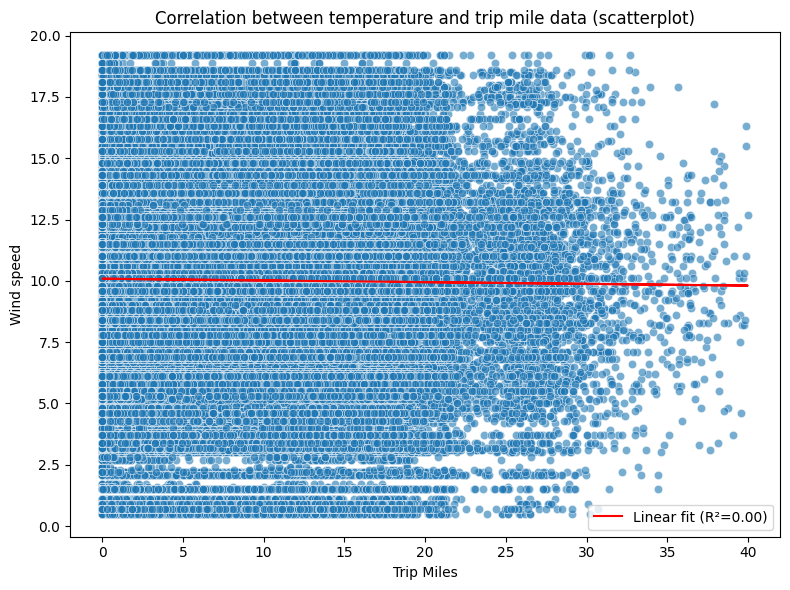

In [89]:
# Drop rows with missing values

fact_taxi_trips_scatter_clean = fact_taxi_trips_full[['trip_miles','wind_speed']].dropna()

# Keep only short trips (trip mile under 40)

fact_taxi_trips_scatter_clean = fact_taxi_trips_scatter_clean[fact_taxi_trips_scatter_clean['trip_miles'] < 40]


# Dimensions

X = fact_taxi_trips_scatter_clean['trip_miles'].values.reshape(-1,1)
y = fact_taxi_trips_scatter_clean['wind_speed'].values

# Linear regression

model = LinearRegression()
model.fit(X, y)

# Predicted values
y_pred = model.predict(X)

# R² score
r2 = r2_score(y, y_pred)
print(f"R² = {r2:.3f}")

# Scatterplot
plt.figure(figsize=(8, 6))
sns.scatterplot(x='trip_miles', y='wind_speed', data=fact_taxi_trips_scatter_clean, alpha=0.6)

# Regression line
plt.plot(fact_taxi_trips_scatter_clean['trip_miles'], y_pred, color='red', label=f'Linear fit (R²={r2:.2f})')

plt.xlabel('Trip Miles')
plt.ylabel('Wind speed')
plt.title('Correlation between temperature and trip mile data (scatterplot)')
plt.legend()
plt.tight_layout()
plt.show()